In [ ]:
import os
import shutil
import random
import kagglehub
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

EPOCHS = 60
BATCH_SIZE = 32
IMG_SIZE = (150, 150)
BASE_DIR = '/content/my_dataset'

## **PHẦN 1: CHUẨN BỊ VÀ CÂN BẰNG DỮ LIỆU**
Tải dataset gốc từ Kaggle. Dữ liệu thực tế thường bị mất cân bằng. Thuật toán dưới đây sẽ tự động tìm thư mục ảnh, lọc các file lỗi và chia đều số lượng ảnh cho mỗi lớp theo chuẩn: **800 Train - 200 Valid - 200 Test**

In [ ]:
path = kagglehub.dataset_download("utkarshsaxenadn/fast-food-classification-dataset")

true_train_path = ""
for root, dirs, files in os.walk(path):
    if "Train" in dirs and len(os.listdir(os.path.join(root, "Train"))) > 0:
        true_train_path = os.path.join(root, "Train")
        break

if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

classes = sorted([d for d in os.listdir(true_train_path) if os.path.isdir(os.path.join(true_train_path, d))])[:10]
for cls in classes:
    for split in ['Train', 'Valid', 'Test']:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

    src = os.path.join(true_train_path, cls)
    imgs = [f for f in os.listdir(src) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.seed(42)
    random.shuffle(imgs)
    for i, f in enumerate(imgs[:800]):
        if i < 500: dest = 'Train'
        elif i < 650: dest = 'Valid'
        else: dest = 'Test'
        shutil.copy(os.path.join(src, f), os.path.join(BASE_DIR, dest, cls, f))

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Train'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Valid'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

100%|██████████| 821M/821M [00:09<00:00, 92.7MB/s]

Extracting files...


Found 5000 files belonging to 10 classes.
Found 1500 files belonging to 10 classes.


 ## **PHẦN 2: MÔ HÌNH CƠ BẢN- BASELINE CNN - PHASE 1**
Xây dựng mạng CNN thuần túy, độ sâu vừa phải, KHÔNG có tính năng Tăng cường dữ liệu. Mô hình này đóng vai trò làm điểm chuẩn để chứng minh tính hiệu quả của Phase 2.

Epoch 1/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.1484 - loss: 2.2566 - val_accuracy: 0.2120 - val_loss: 2.1795
Epoch 2/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.2248 - loss: 2.1348 - val_accuracy: 0.2427 - val_loss: 2.0774
Epoch 3/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.2486 - loss: 2.0687 - val_accuracy: 0.2880 - val_loss: 2.0261
Epoch 4/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.2824 - loss: 2.0171 - val_accuracy: 0.2960 - val_loss: 2.0259
Epoch 5/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3018 - loss: 1.9787 - val_accuracy: 0.2667 - val_loss: 2.0429
Epoch 6/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.3222 - loss: 1.9392 - val_accuracy: 0.3327 - val_loss: 1.9055
Epoch 7/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3348 - loss: 1.9059 - val_accuracy: 0.3087 - val_loss: 1.9536
Epoch 8/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.3416 - loss: 1.8805 - val_

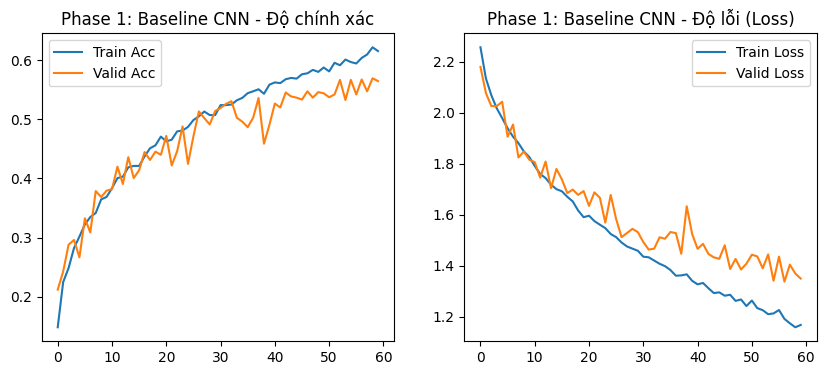

In [ ]:
def build_baseline():
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),

        layers.GlobalAveragePooling2D(name="feature_layer"),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model_p1 = build_baseline()
history_p1 = model_p1.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

model_p1.save('baseline_model_p1.keras')

def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Valid Acc')
    plt.title(f'{title} - Độ chính xác')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Valid Loss')
    plt.title(f'{title} - Độ lỗi (Loss)')
    plt.legend()
    plt.show()

plot_history(history_p1, "Phase 1: Baseline CNN")

Vẽ

Found 1500 files belonging to 10 classes.

Đang chạy dự đoán trên 200 ảnh ngẫu nhiên từ tập Test (đảm bảo đa dạng nhãn)...

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)
                precision    recall  f1-score   support

  Baked Potato       0.75      0.86      0.80        21
        Burger       0.71      0.57      0.63        21
Crispy Chicken       0.86      0.86      0.86        29
         Donut       0.56      0.62      0.59        16
         Fries       0.55      0.71      0.62        17
       Hot Dog       0.31      0.33      0.32        15
         Pizza       0.69      0.47      0.56        19
      Sandwich       0.52      0.64      0.57        22
          Taco       0.47      0.33      0.39        24
       Taquito       0.41      0.44      0.42        16

      accuracy                           0.60       200
     macro avg       0.58      0.58      0.58       200
  weighted avg       0.60      0.60      0.60       200



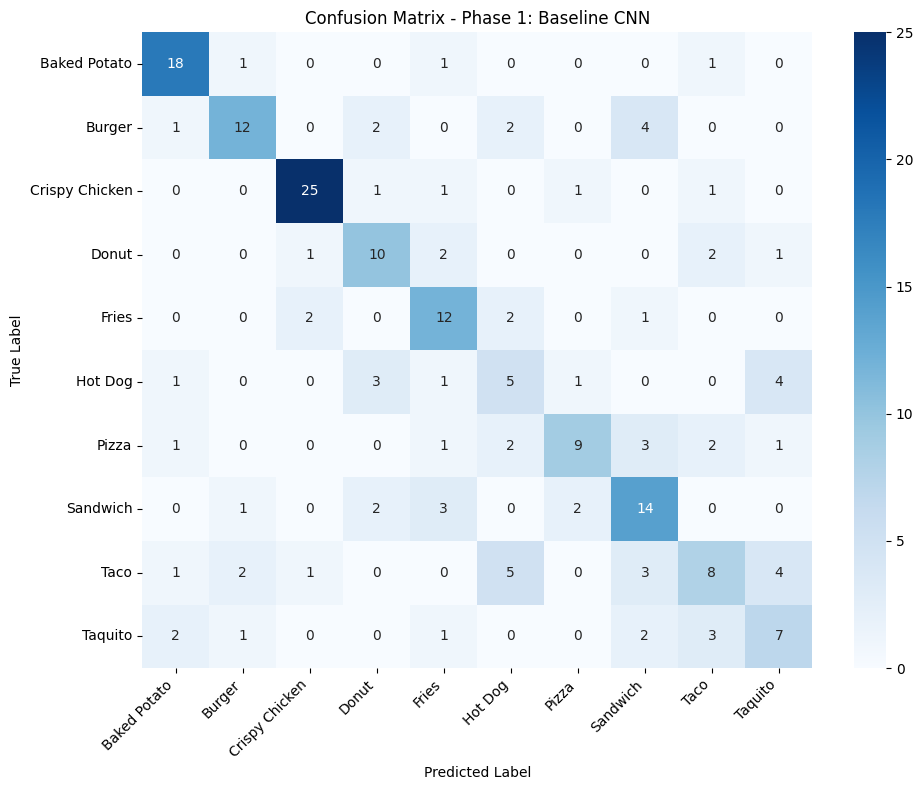

In [ ]:
import numpy as np

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

class_names = test_ds.class_names

print("\nĐang chạy dự đoán trên 200 ảnh ngẫu nhiên từ tập Test (đảm bảo đa dạng nhãn)...")
y_true = []
y_pred_probs = []

count = 0
limit = 200

for images, labels in test_ds:
    if count >= limit: break

    batch_size_actual = images.shape[0]
    if count + batch_size_actual > limit:
        needed = limit - count
        images = images[:needed]
        labels = labels[:needed]

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model_p1.predict(images, verbose=0)
    y_pred_probs.extend(preds)

    count += images.shape[0]

y_pred = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*60)
print(f"BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - Phase 1: Baseline CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
feature_extractor = models.Sequential(model_p1.layers[:-1])

image_batches = []
for imgs, labs in train_ds.take(20):
    image_batches.append(imgs)
images_only = np.concatenate(image_batches, axis=0)

features = feature_extractor.predict(images_only, verbose=0)
features_cos = normalize(features)

kmeans = KMeans(n_clusters=10, random_state=42).fit(features_cos)

joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

Epoch 1/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.1208 - loss: 2.2883 - val_accuracy: 0.1660 - val_loss: 2.2373
Epoch 2/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.1694 - loss: 2.2350 - val_accuracy: 0.1747 - val_loss: 2.2138
Epoch 3/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.1706 - loss: 2.2238 - val_accuracy: 0.1800 - val_loss: 2.1990
Epoch 4/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.1690 - loss: 2.2120 - val_accuracy: 0.1720 - val_loss: 2.1861
Epoch 5/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.1846 - loss: 2.1951 - val_accuracy: 0.2087 - val_loss: 2.1593
Epoch 6/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.2068 - loss: 2.1517 - val_accuracy: 0.2040 - val_loss: 2.1425
Epoch 7/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.2214 - loss: 2.1327 - val_accuracy: 0.2140 - val_loss: 2.1297
Epoch 8/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.2484 - loss: 2.0807 - val_

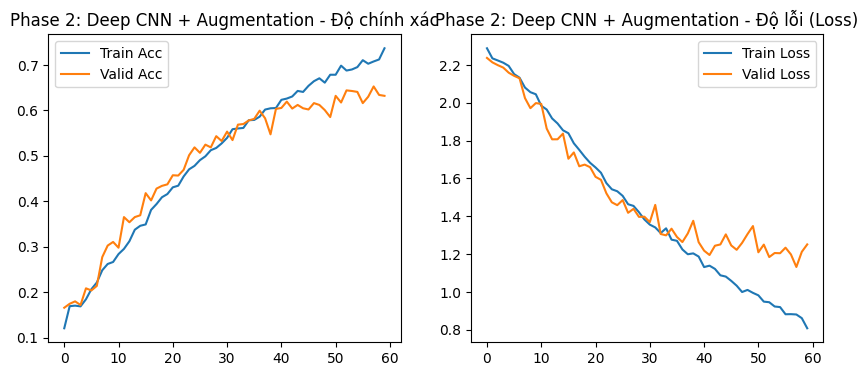

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="module_tang_cuong")

model_p2 = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_p2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_p2 = model_p2.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

model_p2.save('augmented_model_p2.keras')

plot_history(history_p2, "Phase 2: Deep CNN + Augmentation")

Vẽ



BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - PHASE 2
                precision    recall  f1-score   support

  Baked Potato       0.65      0.83      0.73        18
        Burger       0.72      0.62      0.67        21
Crispy Chicken       0.76      0.70      0.73        23
         Donut       0.67      0.70      0.68        23
         Fries       0.68      0.65      0.67        23
       Hot Dog       0.41      0.75      0.53        16
         Pizza       0.75      0.32      0.44        19
      Sandwich       0.72      0.62      0.67        21
          Taco       0.35      0.45      0.39        20
       Taquito       0.55      0.38      0.44        16

      accuracy                           0.60       200
     macro avg       0.63      0.60      0.60       200
  weighted avg       0.64      0.60      0.60       200



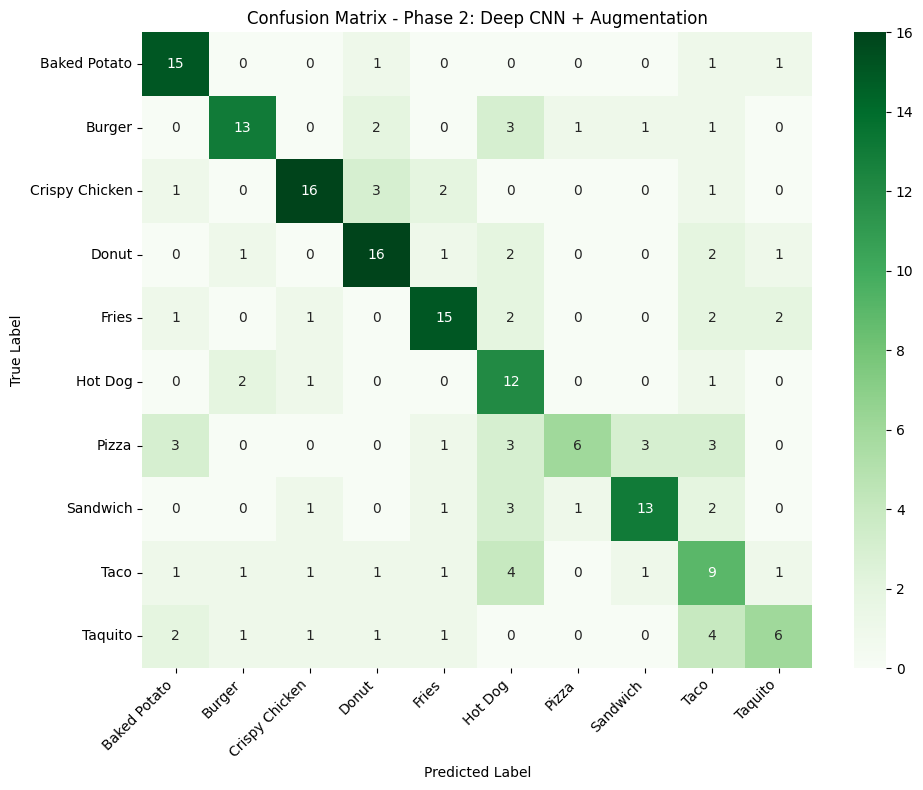

In [ ]:
y_true_p2 = []
y_pred_probs_p2 = []

count = 0
limit = 200

for images, labels in test_ds:
    if count >= limit: break

    batch_size_actual = images.shape[0]
    if count + batch_size_actual > limit:
        needed = limit - count
        images = images[:needed]
        labels = labels[:needed]

    y_true_p2.extend(np.argmax(labels.numpy(), axis=1))
    preds = model_p2.predict(images, verbose=0)
    y_pred_probs_p2.extend(preds)

    count += images.shape[0]

y_pred_p2 = np.argmax(y_pred_probs_p2, axis=1)

print("\n" + "="*60)
print(f"BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - PHASE 2")
print("="*60)
print(classification_report(y_true_p2, y_pred_p2, target_names=class_names))

cm_p2 = confusion_matrix(y_true_p2, y_pred_p2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_p2, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)

plt.title(f'Confusion Matrix - Phase 2: Deep CNN + Augmentation')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()